In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
# Download S&P500 constituents (top 10 stocks)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'JNJ']

In [4]:
# Set date range
start_date = '2020-01-01'
end_date = '2024-12-31'
window = 60  # Rolling window for beta calculation

In [5]:
# Download data
print("Downloading data...")
stock_prices = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close']
spy_prices = yf.download('^GSPC', start=start_date, end=end_date, progress=False)['Close']

In [6]:
# Calculate returns
stock_returns = stock_prices.pct_change().dropna()
market_returns = spy_prices.pct_change().dropna()

# Create equally weighted portfolio
weights = np.ones(len(tickers)) / len(tickers)
portfolio_returns = stock_returns.dot(weights)

In [7]:
# Calculate rolling beta of portfolio vs S&P500
def calculate_rolling_beta(portfolio_returns, market_returns, window):
    """Calculate rolling beta between portfolio and market"""
    rolling_cov = portfolio_returns.rolling(window).cov(market_returns)
    rolling_var = market_returns.rolling(window).var()
    rolling_beta = rolling_cov / rolling_var
    return rolling_beta

In [45]:
# Calculate rolling beta
print("Calculating rolling beta...")
rolling_beta = calculate_rolling_beta(portfolio_returns, market_returns, window)

# Display results
print(f"\nCurrent Portfolio Beta: {rolling_beta.iloc[-1, 0]:.3f}")
print(f"Average Beta (full period): {rolling_beta.mean().iloc[0]:.3f}")
print(f"Beta Range: [{rolling_beta.min().iloc[0]:.3f}, {rolling_beta.max().iloc[0]:.3f}]")

Calculating rolling beta...

Current Portfolio Beta: 1.264
Average Beta (full period): 1.266
Beta Range: [0.915, 1.560]


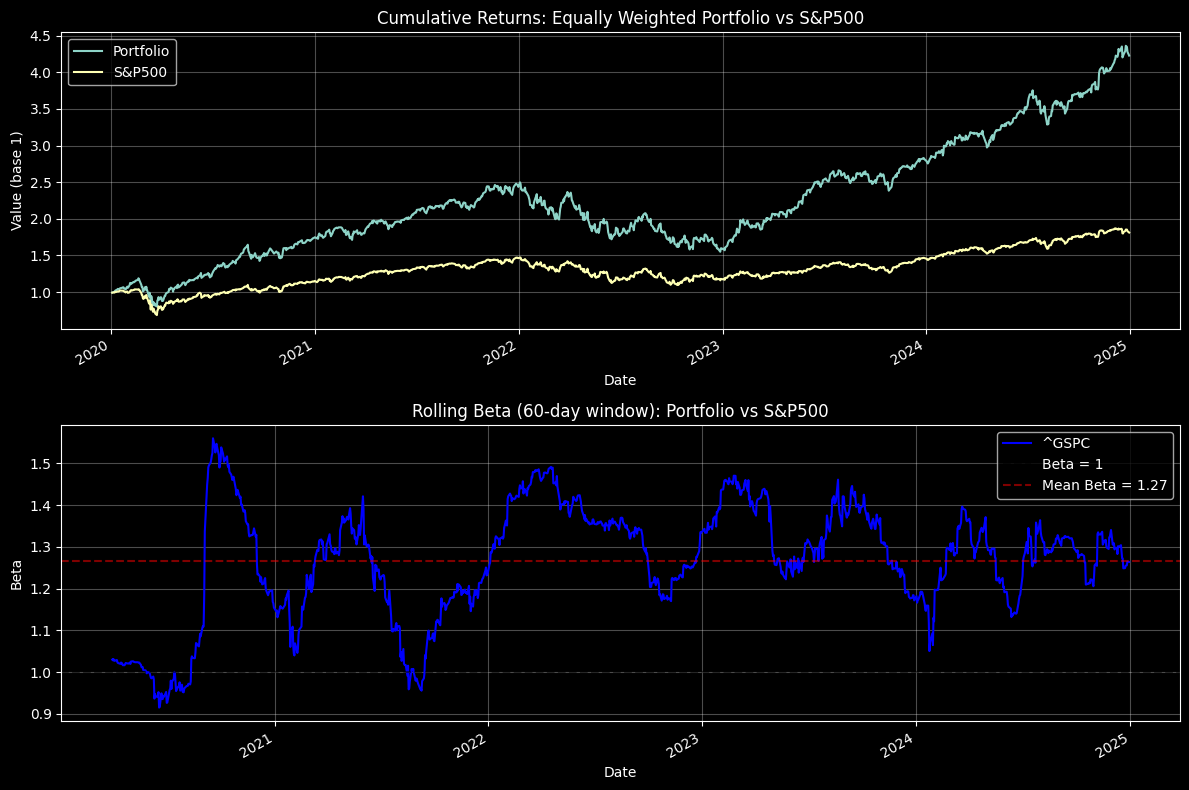

In [77]:
# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Cumulative returns
cumulative_returns = pd.DataFrame({
    'Portfolio': (1 + portfolio_returns).cumprod(),
    'S&P500': (1 + market_returns).cumprod()['^GSPC']
})

cumulative_returns.plot(ax=axes[0])
axes[0].set_title('Cumulative Returns: Equally Weighted Portfolio vs S&P500')
axes[0].set_ylabel('Value (base 1)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left')

# Plot 2: Rolling beta
rolling_beta.plot(ax=axes[1], color='blue')
axes[1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Beta = 1')
axes[1].axhline(y=rolling_beta.mean().iloc[0], color='red', linestyle='--', alpha=0.5, label=f'Mean Beta = {rolling_beta.mean().iloc[0]:.2f}')
axes[1].set_title(f'Rolling Beta ({window}-day window): Portfolio vs S&P500')
axes[1].set_ylabel('Beta')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [83]:
# Summary statistics
print("\n=== PORTFOLIO STATISTICS ===")
print(f"Annual Return: {portfolio_returns.mean() * 252:.2%}")
print(f"Annual Volatility: {portfolio_returns.std() * np.sqrt(252):.2%}")
print(f"Correlation with S&P500: {portfolio_returns.corr(market_returns['^GSPC']):.3f}")


=== PORTFOLIO STATISTICS ===
Annual Return: 32.69%
Annual Volatility: 27.33%
Correlation with S&P500: 0.920
